In [105]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
    plot_electricity_mix,
)

In [106]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50__24H-T-H-B-I-A-dist1_2025.nc')

INFO:pypsa.io:Imported network base_s_50__24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [107]:
from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
    df_2024_power,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)
df_2024_power = bcm_to_twh(df_2024_power)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [108]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [109]:
def plot_power_demand(ax_left, ax_right, n, right_data, fig, i):

    add_shared_row_title(fig, ax_left, ax_right, "EU-27 + UK Power Sector Gas Demand", i)

    powergas = n.links.index[n.links.carrier.isin(['OCGT', 'CCGT'])]
    gas_consumption = n.links_t.p0[powergas].sum(axis=1).mul(n.snapshot_weightings['generators']).mul(1e-6)
    gas_consumption = gas_consumption.groupby(gas_consumption.index.month).sum()

    model_data = gas_consumption.copy()
    model_data.index = right_data.index

    ylim_lower = min(0, right_data.min(), model_data.min())
    ylim_upper = max(right_data.max(), model_data.max())

    pad = 1.1

    ax_left.plot(model_data.index, model_data.values, marker='o', color='royalblue')
    ax_right.plot(right_data.index, right_data.values, marker='o', color='royalblue')

    ax_left.set_ylim(ylim_lower, ylim_upper * pad)
    ax_right.set_ylim(ylim_lower, ylim_upper * pad)

    for ax in [ax_left, ax_right]:
        basic_axis_formatting(ax)

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

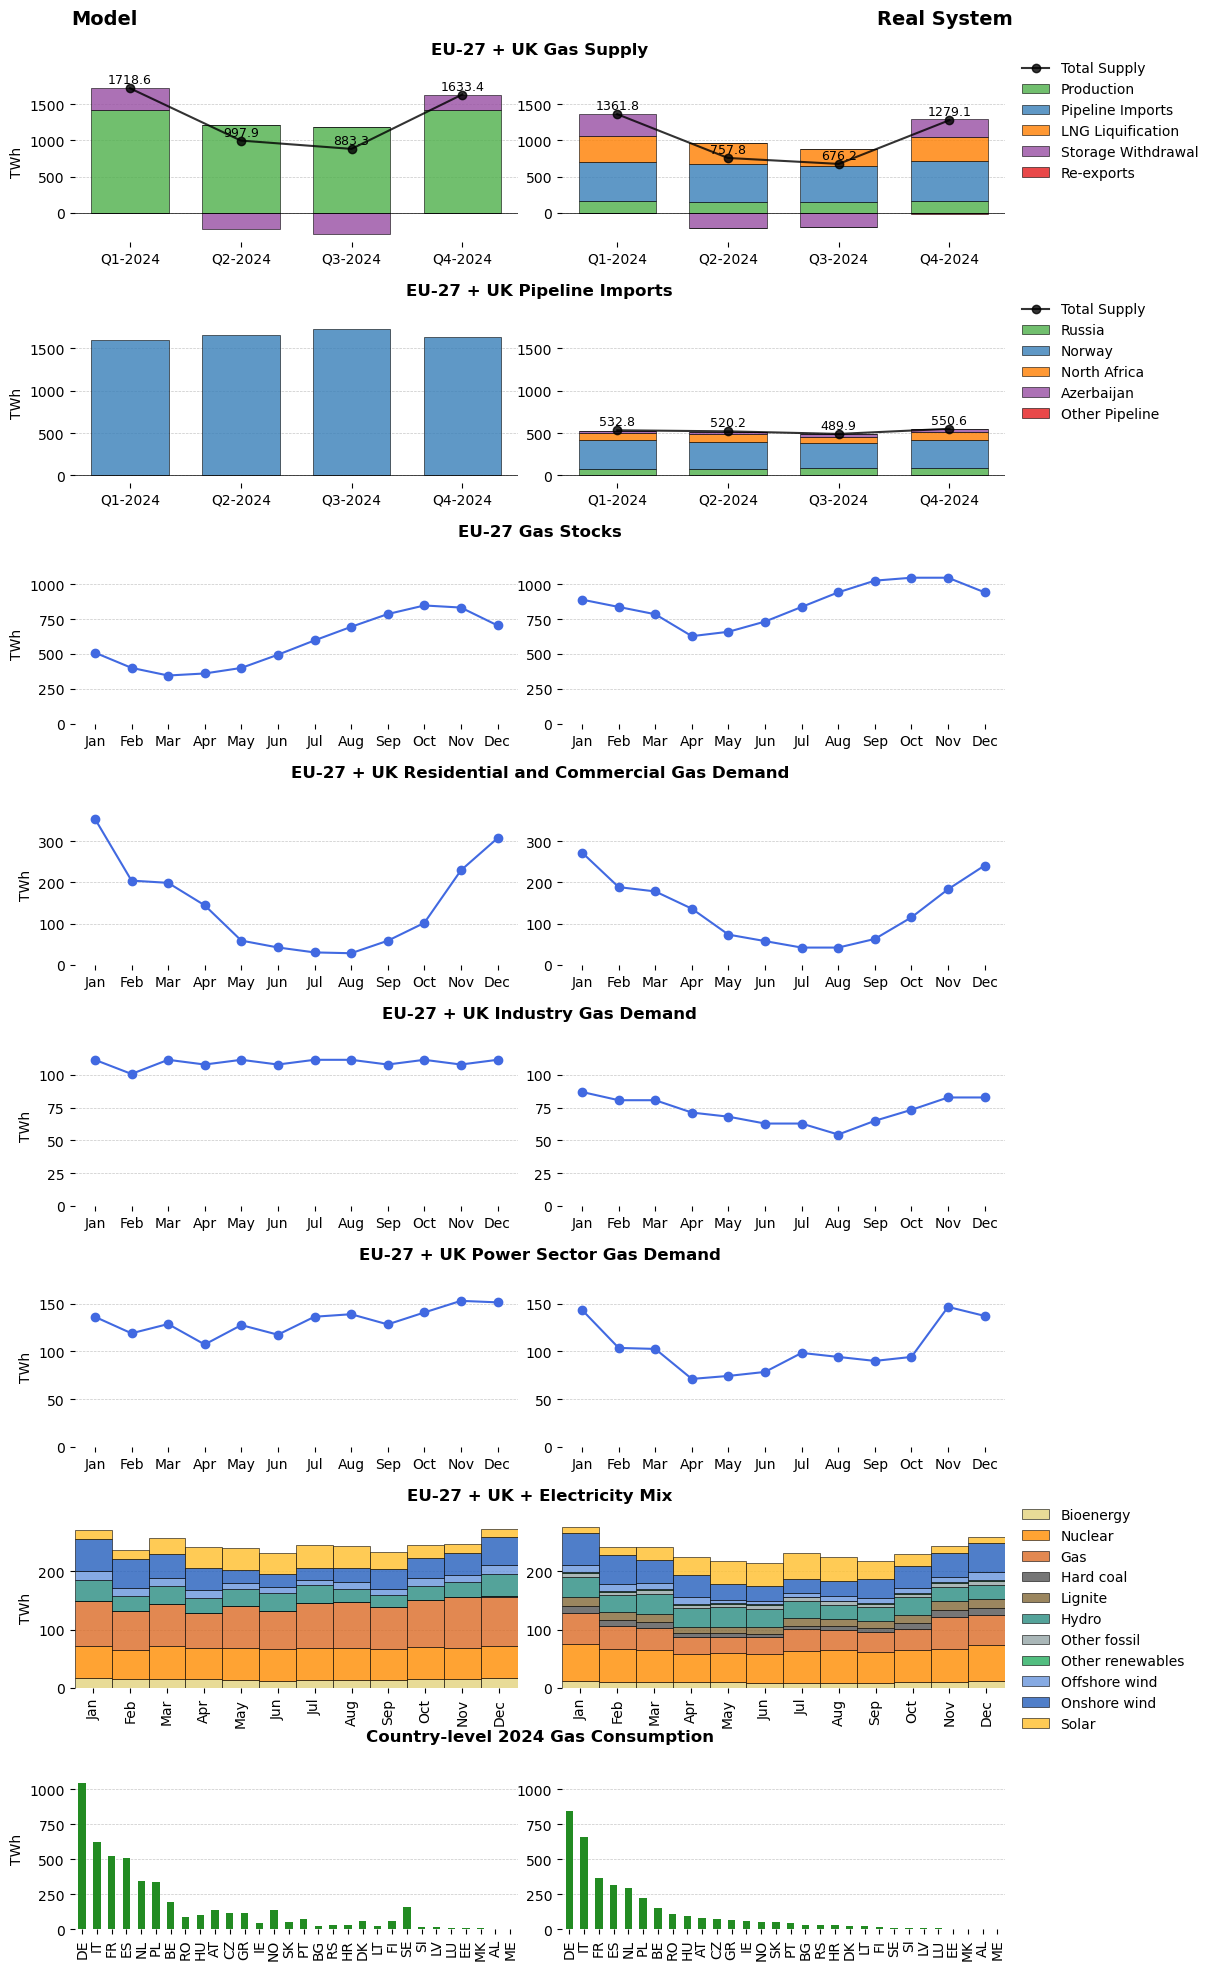

In [110]:
nrows = 8

fig_height = 3 * nrows  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_power_demand,
    plot_electricity_mix,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    df_2024_power,
    None,
    ccon,
]

for i in range(nrows):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

fig.text(0.15, 0.91, 'Model', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text(0.85, 0.91, 'Real System', ha='center', va='top', fontsize=14, fontweight='bold')

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

# plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()

In [111]:
ss = n.statistics.energy_balance(groupby=['carrier', 'bus'])

ss.loc[
    (ss.index.get_level_values(2).str.contains('gas')) &
    (ss.index.get_level_values(2).str.contains('NO')) &
    (ss.index.get_level_values(1) == 'gas pipeline')
]

component  carrier       bus      
Link       gas pipeline  NO1 0 gas   -6622.09371
dtype: float64

In [112]:
pipes = n.links.index[n.links.carrier == 'gas pipeline']

In [113]:
def get_link_data(c):
    l = n.links.index[n.links.carrier == c]

    cols = ['marginal_cost', 'efficiency', 'capital_cost', 'p_nom', 'p_nom_opt']
    print(n.links.loc[[l[0]], cols])

In [114]:
get_link_data('OCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 OCGT-2025       1.938051       0.405  19739.577493    0.0   0.013824


In [115]:
get_link_data('CCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 CCGT-2025       2.603594        0.57   61475.63654    0.0   0.011888


In [116]:
get_link_data('coal')

                 marginal_cost  efficiency   capital_cost        p_nom  \
Link                                                                     
DE0 2 coal-1950       1.170885       0.356  120046.057771  2134.831461   

                   p_nom_opt  
Link                          
DE0 2 coal-1950  2134.831461  


In [117]:
ss = n.links.loc[n.links.carrier.isin(['OCGT', 'CCGT', 'coal', 'lignite'])]
ss.groupby('carrier')[['p_nom', 'p_nom_opt']].sum() / 1e3

,p_nom,p_nom_opt
carrier,,
CCGT,320.815959,349.887006
OCGT,0.057556,16.417980
coal,137.859267,137.859267
lignite,157.953647,157.953647


In [118]:
n.generators.loc[n.generators.carrier.isin(['gas', 'coal', 'lignite']), ['marginal_cost', 'capital_cost', 'carrier']].groupby('carrier').mean()

,marginal_cost,capital_cost
carrier,,
coal,9.564945,0.0
gas,24.577938,0.0
lignite,3.308602,0.0


In [119]:
prices = pd.read_csv(
    Path.cwd().parent / 'data' / 'TERMINAL - PA historical - 2025-10-21.csv', index_col=0, parse_dates=True
)

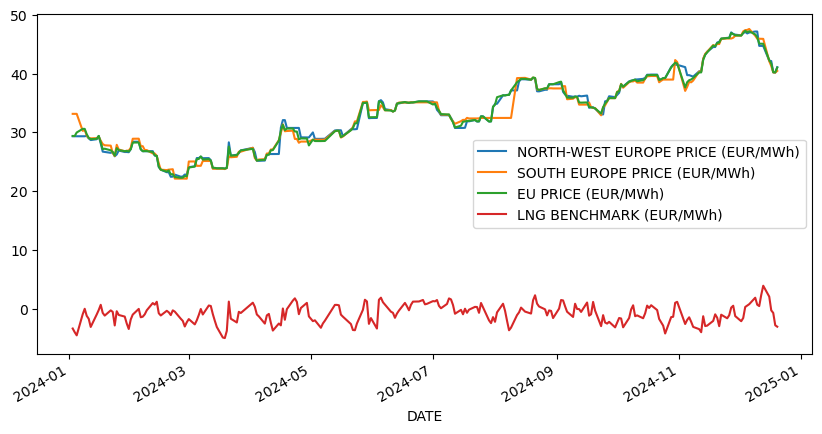

In [120]:
fig, ax = plt.subplots(figsize=(10, 5))
prices.index = pd.to_datetime(prices.index)
prices.loc['2024'].plot(ax=ax)
plt.show()

In [121]:
wbprices = pd.read_excel(
    Path.cwd().parent / 'data' / 'CMO-Historical-Data-Monthly.xlsx', sheet_name='Monthly Prices', header=[4,5,6], index_col=0, parse_dates=True,
)
wbprices = wbprices.loc[wbprices.index.str.contains('2024')]

gas_keepers = ['Natural gas, Europe', 'Liquefied natural gas, Japan']
coal_keepers = ['Coal, Australian', 'Coal, South African **']

wbprices = wbprices.loc[:, gas_keepers + coal_keepers]
wbprices.index = list(map(lambda x: f'{x[:4]}-{x[-2:]}', wbprices.index))

wbprices.columns = wbprices.columns.get_level_values(0)

wbprices.loc[:, gas_keepers] *= 3.152 # conversion from $/MMBtu to EUR/MWh

wbprices.loc[:, 'Lignite'] = 0.1325 * 6000 / 2800 * wbprices.loc[:, 'Coal, Australian']
 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, Australian'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, South African **'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)

wbprices.rename(
    columns={
        'Natural gas, Europe': 'Europe gas',
        'Liquefied natural gas, Japan': 'Japan LNG',
        'Coal, Australian': 'Australia coal',
        'Coal, South African **': 'South Africa coal',
    },
    inplace=True,
)
wbprices.index = pd.to_datetime(wbprices.index)

/tmp/ipykernel_204804/3515084156.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wbprices = pd.read_excel(


In [122]:
em = pd.read_csv(
    Path.cwd().parent / 'data' / 'europe_monthly_full_release_long_format.csv', index_col=[1,2]
)

em = em.loc[
    (em['Unit'] == 'TWh') &
    (em['Subcategory'] == 'Fuel')
    ]

In [123]:
em = em.set_index('Variable', append=True)
em = em.loc[em.Area.isin(['EU', 'United Kingdom'])]

em = em.groupby([em.index.get_level_values(2), em.index.get_level_values(1).str[:7]])['Value'].sum().unstack()
em = em.loc[:, em.columns.str.contains('2024')]

In [124]:
em.sum().sum()

2825.89

In [125]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [126]:
w = n.snapshot_weightings.generators.iloc[0]

In [127]:
el = n.loads.index[(n.loads.carrier == 'electricity') & (~n.loads.index.str.contains(' NO'))]
total_elec_load = (
    n.loads.loc[
        n.loads.carrier.isin(['agriculture electricity', 'industry electricity']) &
        (~n.loads.index.str.contains(' NO')),
        'p_set'].sum() * len(n.snapshots) +
    n.loads_t.p_set.loc[:, el].sum().sum()
) * w * 1e-6
withdrawers = n.links.loc[list(map(lambda x: 'low voltage' in x, n.links.bus0))].index
withdrawers = withdrawers[~withdrawers.str.contains('NO ')]
heating_transport_demand = n.links_t.p0.loc[:, withdrawers].sum().sum() * w * 1e-6

total_elec_load += heating_transport_demand
total_elec_load

2980.1716523864893

In [128]:
n.stores.loc[n.stores.carrier == 'gas', ['e_nom', 'e_nom_opt']].mul(1e-6).sum()

e_nom           0.000000
e_nom_opt    1331.870641
dtype: float64

In [129]:
demands = ['urban central heat', 'urban decentral heat', 'rural heat']

heat_buses = n.buses.index[n.buses.carrier.isin(demands)]

heat_generators = n.generators.index[n.generators.bus.isin(heat_buses)]
heat_generator_carriers = n.generators.loc[heat_generators, 'carrier'].unique()

heat_links = n.links.index[n.links.bus0.isin(heat_buses) | n.links.bus1.isin(heat_buses) | n.links.bus2.isin(heat_buses) | n.links.bus3.isin(heat_buses)]
heat_link_carriers = n.links.loc[heat_links, 'carrier'].unique()

heat_loads = n.loads.index[n.loads.bus.isin(heat_buses)]
heat_load_carriers = n.loads.loc[heat_loads, 'carrier'].unique()

all_heat_carriers = pd.Index(heat_generator_carriers).union(pd.Index(heat_link_carriers))

In [130]:
import yaml

with open(Path.cwd().parent / 'config.basicrun.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [131]:
idx = pd.IndexSlice

eb = n.statistics.energy_balance(groupby=['carrier', 'bus'])
eb = eb.loc[idx[:, :, heat_buses]]
eb = eb.groupby([eb.index.get_level_values(1), eb.index.get_level_values(2).str[:2]]).sum()
eb = eb.loc[eb > 0].unstack().replace(np.nan, 0)
eb = eb.loc[eb.sum(axis=1).sort_values(ascending=False).index, eb.sum().sort_values(ascending=False).index].mul(1e-6)

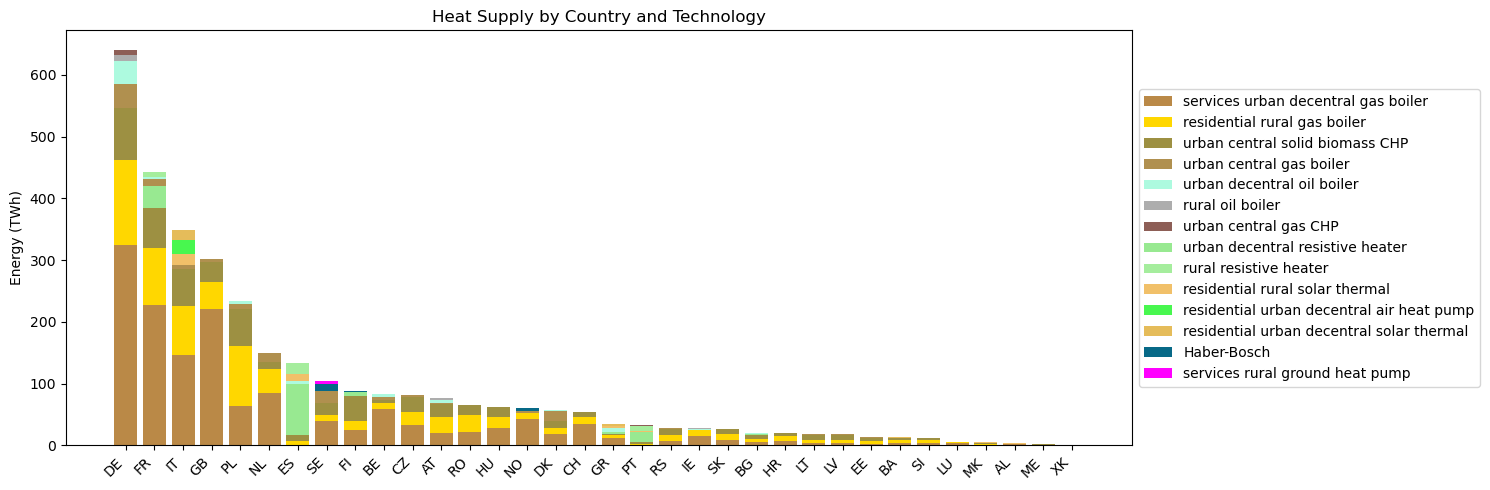

In [132]:
fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(eb.columns):
    col_data = eb[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Energy (TWh)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [133]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [134]:
ss = n.links.loc[n.links.carrier.isin(eb.index)]
ss = ss.groupby(['carrier', 'bus1'])['p_nom_opt'].sum().unstack()
ss = ss.T.groupby(ss.columns.str[:2]).sum().T.mul(1e-3)
ss.columns = ss.columns.str[:2]
ss = ss.loc[ss.sum(axis=1) > 0]
ss = ss.loc[:, ss.sum().sort_values(ascending=False).index]

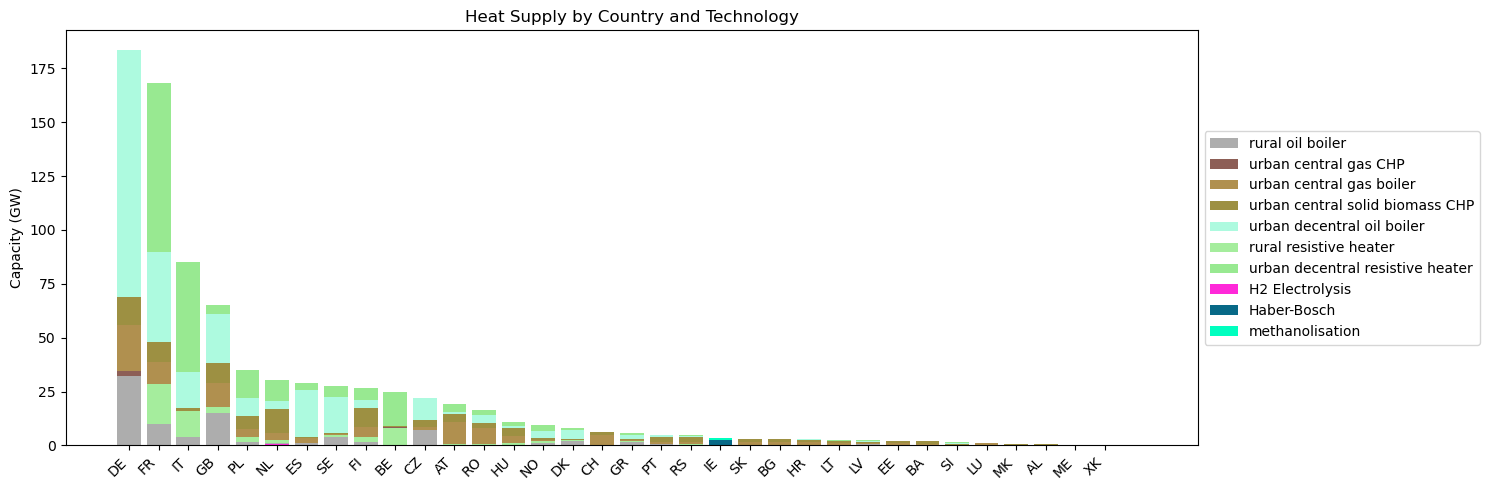

In [135]:

fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(ss.columns):
    col_data = ss[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Capacity (GW)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [136]:
cf = n.statistics()['Capacity Factor']

In [137]:
n.links.index[n.links.index.str.contains('residential')]

Index([], dtype='object', name='Link')

In [138]:
'residential urban decentral gas boiler' in n.links.carrier.unique()

False

In [139]:
heat_carriers = [
    'urban decentral heat',
    # 'urban central heat',
    'rural heat',
]

heat_buses = n.buses.index[
    n.buses.carrier.isin(heat_carriers)
    ]

carriers = n.links.loc[n.links.bus1.isin(heat_buses), 'carrier'].unique()

supply = pd.DataFrame(index=n.snapshots, columns=carriers)

for c in carriers:
    supply.loc[:, c] = n.links_t.p1.loc[:, n.links.carrier == c].sum(axis=1).mul(-1e-3)

supply = supply.groupby(lambda x: ' '.join(x.split()[-2:]), axis=1).sum()
supply = supply.div(supply.sum(axis=1), axis=0)

/tmp/ipykernel_204804/880755503.py:18: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  supply = supply.groupby(lambda x: ' '.join(x.split()[-2:]), axis=1).sum()


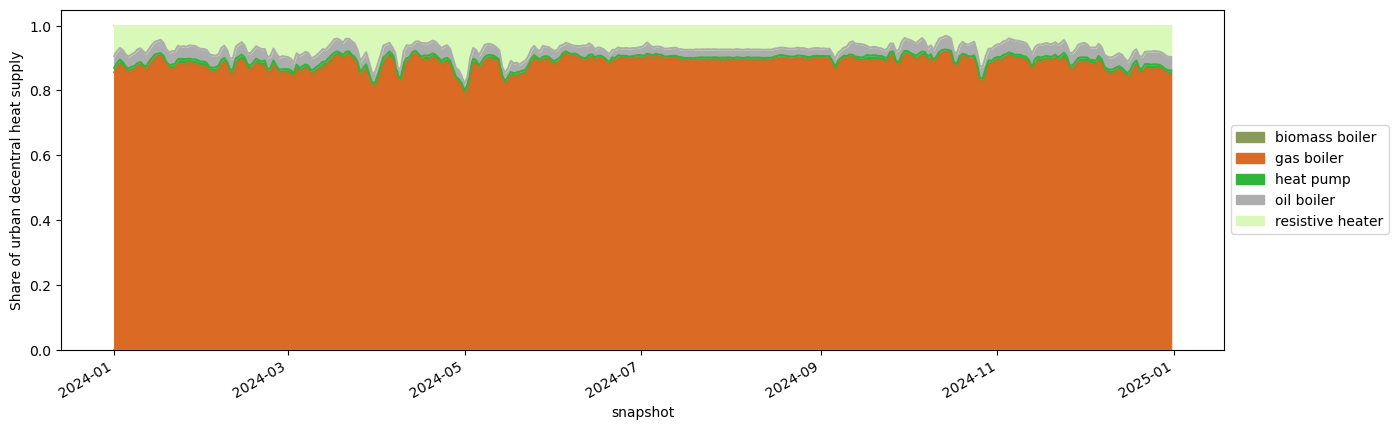

In [140]:
fig, ax = plt.subplots(figsize=(15, 5))
import random
colors = [tech_colors.get(carrier, f'#{random.randint(0, 0xFFFFFF):06x}') for carrier in supply.columns]

supply.plot.area(ax=ax, color=colors, legend=False)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Share of urban decentral heat supply')
plt.show()

In [ ]:
wiggle = 0.0001

for bus in heat_buses:

    if not bus.startswith('DE'):
        continue

    busload = n.loads_t.p_set.loc[:, n.loads.index[n.loads.index.str.contains(bus)]]

    inc_links = n.links.index[n.links.bus1 == bus]

    supply_capacities = pd.Series(0, index=inc_links)
    efficiencies = pd.Series(0, index=inc_links)

    profiles = {}

    for link in inc_links:
        if link in n.links_t.efficiency.columns:
            link_eff = n.links_t.efficiency.loc[:, link].mean()
            efficiencies.loc[link] = link_eff
        else:
            link_eff = n.links.loc[link, 'efficiency']
            efficiencies.loc[link] = link_eff

        link_cap = n.links.loc[link, 'p_nom']
        supply_capacities.loc[link] = link_cap * link_eff

    if supply_capacities.sum() == 0:
        continue

    shares = supply_capacities.div(supply_capacities.sum())
    operation_profile = busload / busload.max() * (supply_capacities.sum() / busload.max())

    for link, share in shares.items():

        if 'gas boiler' in n.links.loc[link, 'carrier']:
            continue

        p_pu = share * operation_profile 
        p_pu.columns = [link]

        profiles[link] = p_pu


    print(pd.concat(profiles.values(), axis=1))

    break

DE0 0 rural heat
Load        DE0 0 rural heat
snapshot                    
2024-01-01       4012.972570
2024-01-02       4189.833945
2024-01-03       3271.798448
2024-01-04       5585.358570
2024-01-05       5973.393623
...                      ...
2024-12-27       5566.012737
2024-12-28       6664.584448
2024-12-29       6142.877650
2024-12-30       4838.592842
2024-12-31       5242.041021

[365 rows x 1 columns]
Link
DE0 0 rural air heat pump-2025       0.00
DE0 0 rural biomass boiler-2025      0.00
DE0 0 rural gas boiler-2010          0.17
DE0 0 rural gas boiler-2015          0.17
DE0 0 rural gas boiler-2019          0.14
DE0 0 rural gas boiler-2025          0.00
DE0 0 rural ground heat pump-2010    0.02
DE0 0 rural ground heat pump-2015    0.02
DE0 0 rural ground heat pump-2019    0.01
DE0 0 rural ground heat pump-2025    0.00
DE0 0 rural oil boiler-2010          0.16
DE0 0 rural oil boiler-2015          0.16
DE0 0 rural oil boiler-2019          0.13
dtype: float64
            DE0 

/tmp/ipykernel_204804/1367571308.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.744991858362324' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  efficiencies.loc[link] = link_eff
/tmp/ipykernel_204804/1367571308.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1574.351978634866' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  supply_capacities.loc[link] = link_cap * link_eff


/tmp/ipykernel_169122/2518118413.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


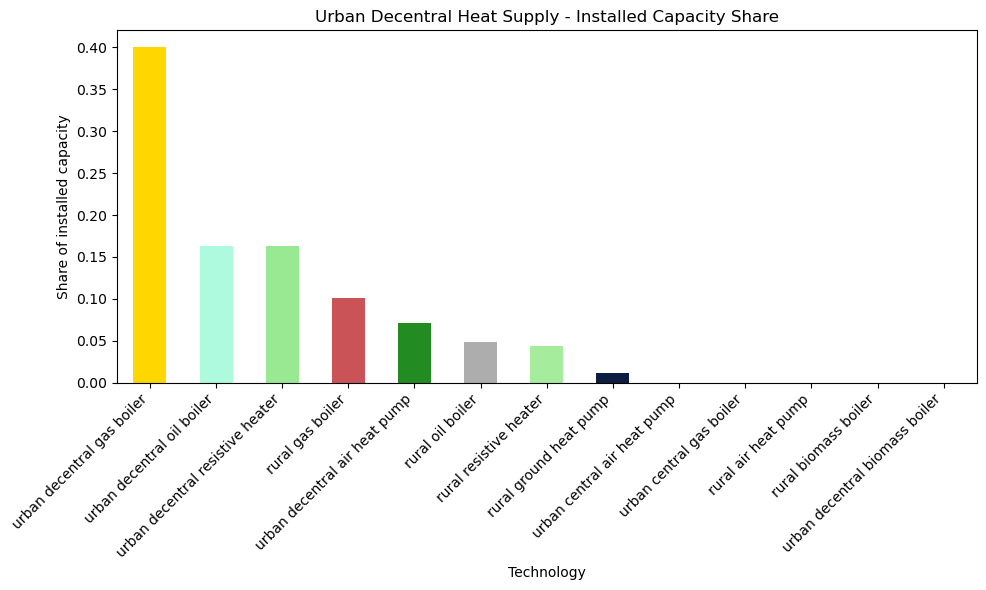

In [176]:
installed_cap = pd.Series(index=carriers)

for c in carriers:

    ls = n.links.index[n.links.carrier == c]

    if ls.isin(n.links_t.efficiency.columns).any():
        assert ls.isin(n.links_t.efficiency.columns).all()

        eff = n.links_t.efficiency.loc[:, ls].mean()
        heat_cap = n.links.loc[ls, 'p_nom_opt'].mul(eff).mul(1e-3)
        installed_cap.loc[c] = heat_cap.sum()

    else:
        installed_cap.loc[c] = n.links.loc[ls, 'p_nom'].mul(1e-3).mul(n.links.loc[ls, 'efficiency']).sum()

installed_cap = installed_cap.sort_values(ascending=False) / installed_cap.sum()
# %% cell 37b code

fig, ax = plt.subplots(figsize=(10, 6))

# Create stacked bar plot
colors = [tech_colors.get(carrier, f'#{random.randint(0, 0xFFFFFF):06x}') for carrier in installed_cap.index]

installed_cap.plot.bar(ax=ax, color=colors, stacked=False)

ax.set_ylabel('Share of installed capacity')
ax.set_xlabel('Technology')
ax.set_title('Urban Decentral Heat Supply - Installed Capacity Share')
ax.legend().set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [132]:
heat_carriers

['urban decentral heat', 'rural heat']

<Axes: xlabel='snapshot'>

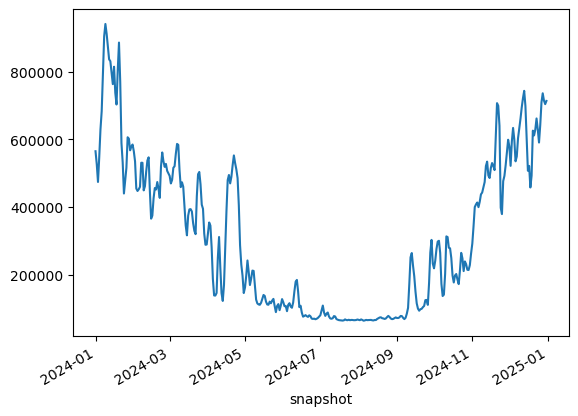

In [157]:
heatloads = n.loads.index[n.loads.carrier.isin(['urban central heat', 'urban decentral heat', 'rural heat'])]
n.loads_t.p_set.loc[:, heatloads.intersection(n.loads_t.p_set.columns)].sum(axis=1).plot()

In [155]:
n.links.loc[n.links.carrier.isin(installed_cap.index)].groupby('carrier')['p_nom_extendable'].first()

carrier
rural air heat pump                  True
rural biomass boiler                 True
rural gas boiler                     True
rural ground heat pump               True
rural oil boiler                    False
rural resistive heater              False
urban central air heat pump         False
urban central gas boiler            False
urban decentral air heat pump        True
urban decentral biomass boiler       True
urban decentral gas boiler           True
urban decentral oil boiler          False
urban decentral resistive heater    False
Name: p_nom_extendable, dtype: bool

<Axes: xlabel='snapshot'>

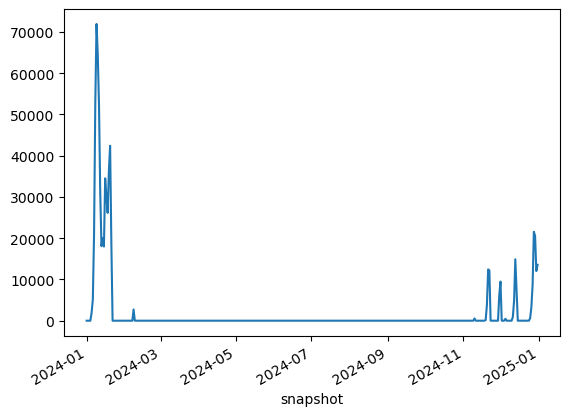

In [ ]:
n.links_t.p0.loc[:, boilers].sum(axis=1).plot()

In [ ]:
caps = n.statistics.optimal_capacity(groupby=['carrier', 'bus']).loc[idx['Link']]
relevant_tech = caps.index.get_level_values(0).unique().intersection(all_heat_carriers)
caps = caps.loc[idx[relevant_tech]]
caps = caps.groupby([caps.index.get_level_values(0), caps.index.get_level_values(1).str[:2]]).sum()
caps = caps.loc[caps > 0].unstack().replace(np.nan, 0)
caps = caps.loc[caps.sum(axis=1).sort_values(ascending=False).index, caps.sum().sort_values(ascending=False).index].mul(1e-3)

In [ ]:
n.links.loc[n.links.carrier == 'urban decentral air heat pump']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,reversed,project_status,geometry,dc,under_construction,voltage,length_original,underground,tags,underwater_fraction
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 urban decentral air heat pump-2025,AL0 0 low voltage,AL0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
AT0 0 urban decentral air heat pump-2010,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2010,18.0,73.469388,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2015,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2015,18.0,73.469388,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2019,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2019,18.0,58.775510,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2025,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE1 0 urban decentral air heat pump-2019,SE1 0 low voltage,SE1 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2019,18.0,279.183673,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
SE1 0 urban decentral air heat pump-2025,SE1 0 low voltage,SE1 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
SI0 0 urban decentral air heat pump-2025,SI0 0 low voltage,SI0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN


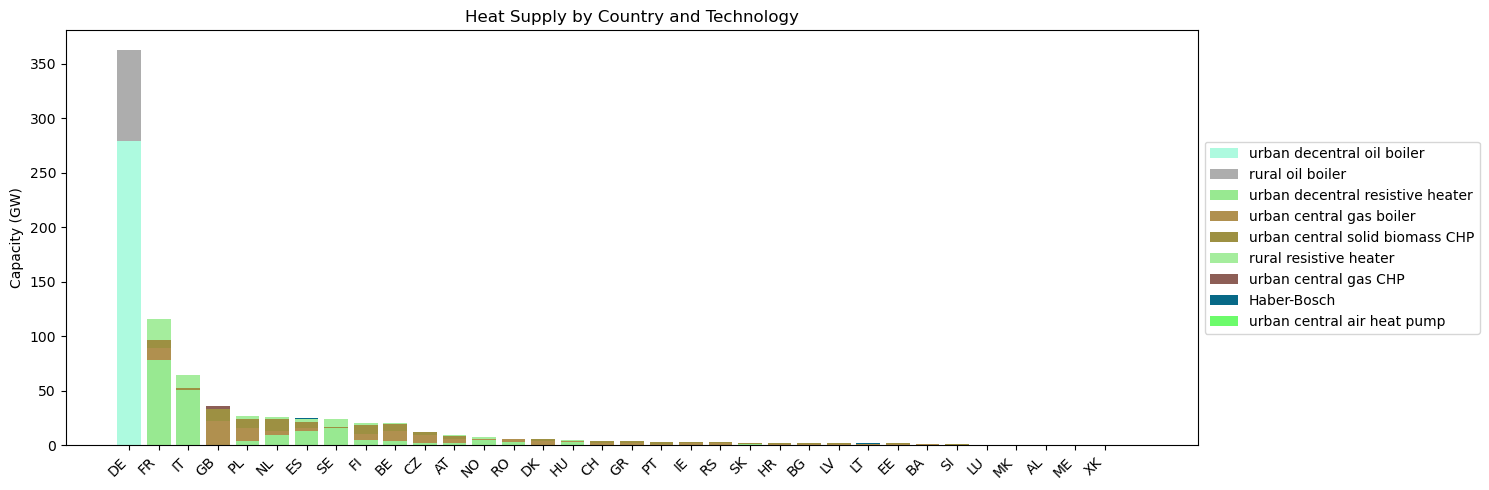

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(caps.columns):
    col_data = caps[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

# Add legend on the right
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates while preserving order
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

# Set x-axis labels
ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Capacity (GW)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [7]:
final_carriers = ['Wind Onshore', 'Wind Offshore', 'Coal', 'Lignite', 'Gas', 'Hydro', 'Nuclear', 'Solar', 'Biomass', 'Waste', 'Geothermal']

In [8]:
eu_mapping = {
    'Biomass': 'Biomass',
    'Waste': 'Waste',
    'Fossil Brown coal/Lignite': 'Lignite',
    'Fossil Hard coal': 'Coal',
    'Fossil Coal-derived gas': 'Gas',
    'Fossil Gas': 'Gas',
    'Fossil Oil': 'Gas',
    'Fossil Oil shale': 'Gas',
    'Fossil Peat': 'Gas',
    'Geothermal': 'Geothermal',
    'Hydro Pumped Storage': 'Hydro',
    'Hydro Run-of-river and poundage': 'Hydro',
    'Hydro Water Reservoir': 'Hydro',
    'Marine': 'Hydro',
    'Nuclear': 'Nuclear',
    'Other': 'Gas',
    'Other renewable': 'Biomass',
    'Solar': 'Solar',
    'Wind Offshore': 'Wind Offshore',
    'Wind Onshore': 'Wind Onshore',
}

uk_mapping = {
    'Coal [note 4]': 'Coal',
    'Oil [note 5]': 'Gas',
    'OCGT and conventional thermal gas [note 5]': 'Gas',
    'CCGT gas': 'Gas',
    'Nuclear - Magnox': 'Nuclear',
    'Nuclear - PWR': 'Nuclear',
    'Nuclear - AGR': 'Nuclear',
    'Hydro (natural flow)': 'Hydro',
    'Wind (onshore)': 'Wind Onshore',
    'Wind (offshore)': 'Wind Offshore',
    'Solar': 'Solar',
    'Wave and tidal': 'Hydro',
    'Bioenergy': 'Biomass',
    'Other fuels [note 6]': 'Gas',
    'Pumped storage [note 7]': 'Hydro',
}

In [9]:
cap = pd.read_csv(
    Path.cwd().parent / 'data' / 'net_generation_capacity_2024.csv', 
    sep='\t',
    index_col=[3,4]
)['ProvidedValue'].unstack().replace(np.nan, 0).groupby(eu_mapping).sum()

In [10]:
idx = pd.IndexSlice

ukcap = pd.read_excel(
    Path.cwd().parent / 'data' / 'DUKES_5.12.xlsx',
    sheet_name='5.12',
    header=6,
    index_col=[0,1]
)['2024'].loc[idx['All']]

In [11]:
ukcap = ukcap.groupby(uk_mapping).sum()
cap['GB'] = ukcap

cap = cap.replace(np.nan, 0)

In [12]:
cap.index

Index(['Biomass', 'Coal', 'Gas', 'Geothermal', 'Hydro', 'Lignite', 'Nuclear',
       'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore'],
      dtype='object', name='Category')

In [13]:
cap


Country,AL,AT,BA,BE,BG,CH,CZ,DE,DK,EE,...,MK,NL,NO,PL,PT,RO,RS,SE,SI,GB
Category,,,,,,,,,,,,,,,,,,,,,
Biomass,0.0,549.00,0.0,730.82,74.0,0.0,870.0,8932.99,0.0,150.3,...,7.0,415.0,113.88,662.30,681.0,118.0,2.38,0.0,43.39,6696.334546
Coal,0.0,0.00,0.0,0.00,356.0,0.0,1200.0,18411.00,0.0,0.0,...,0.0,4006.0,0.00,18830.51,0.0,176.0,0.00,0.0,0.00,6.776299
Gas,97.0,5229.00,0.0,7473.50,699.0,0.0,1620.0,43260.00,0.0,1443.7,...,416.0,18352.0,504.18,7471.29,4460.7,2238.0,641.35,6600.0,814.04,36945.447879
Geothermal,0.0,0.25,0.0,0.00,0.0,0.0,0.0,54.00,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.000000
Hydro,2203.0,11821.00,2148.0,1493.51,3213.0,13103.2,2278.0,14560.80,0.0,8.0,...,644.0,38.0,34600.35,2377.30,8191.9,6139.0,3179.29,16300.0,1305.24,4799.453570
Lignite,0.0,0.00,1883.0,0.00,4119.0,0.0,7200.0,18363.00,0.0,0.0,...,824.0,0.0,0.00,7557.00,0.0,1733.0,6010.50,0.0,1190.50,0.000000
Nuclear,0.0,0.00,0.0,3929.00,2080.0,2970.0,4040.0,0.00,0.0,0.0,...,0.0,486.0,0.00,0.00,0.0,1300.0,0.00,6900.0,696.00,5883.000000
Solar,195.0,7294.00,29.9,8788.79,4055.0,0.0,3548.0,76600.56,3730.0,812.0,...,0.0,24261.0,9.07,14608.70,1810.8,1293.0,29.13,3200.0,1109.53,18260.239221
Waste,0.0,80.00,0.0,383.64,6.0,0.0,100.0,1808.00,0.0,17.0,...,0.0,786.0,91.96,0.00,0.0,0.0,32.40,0.0,6.31,0.000000


In [14]:
plot_carriers = [
    ('Biomass', ['urban central solid biomass CHP'], 'links'),
    ('Gas', ['OCGT', 'CCGT'], 'links'),
    ('Coal', ['coal'], 'links'),
    ('Lignite', ['lignite'], 'links'),
    ('Nuclear', ['nuclear'], 'links'),
    ('Hydro', ['ror', 'hydro', 'PHS'], ['generators', 'storage_units', 'storage_units']),
    ('Solar', ['solar', 'solar-hsat', 'solar rooftop'], 'generators'),
    ('Wind Onshore', ['onwind'], 'generators'),
    ('Wind Offshore', ['offwind-ac', 'offwind-dc', 'offwind-float'], 'generators')
]

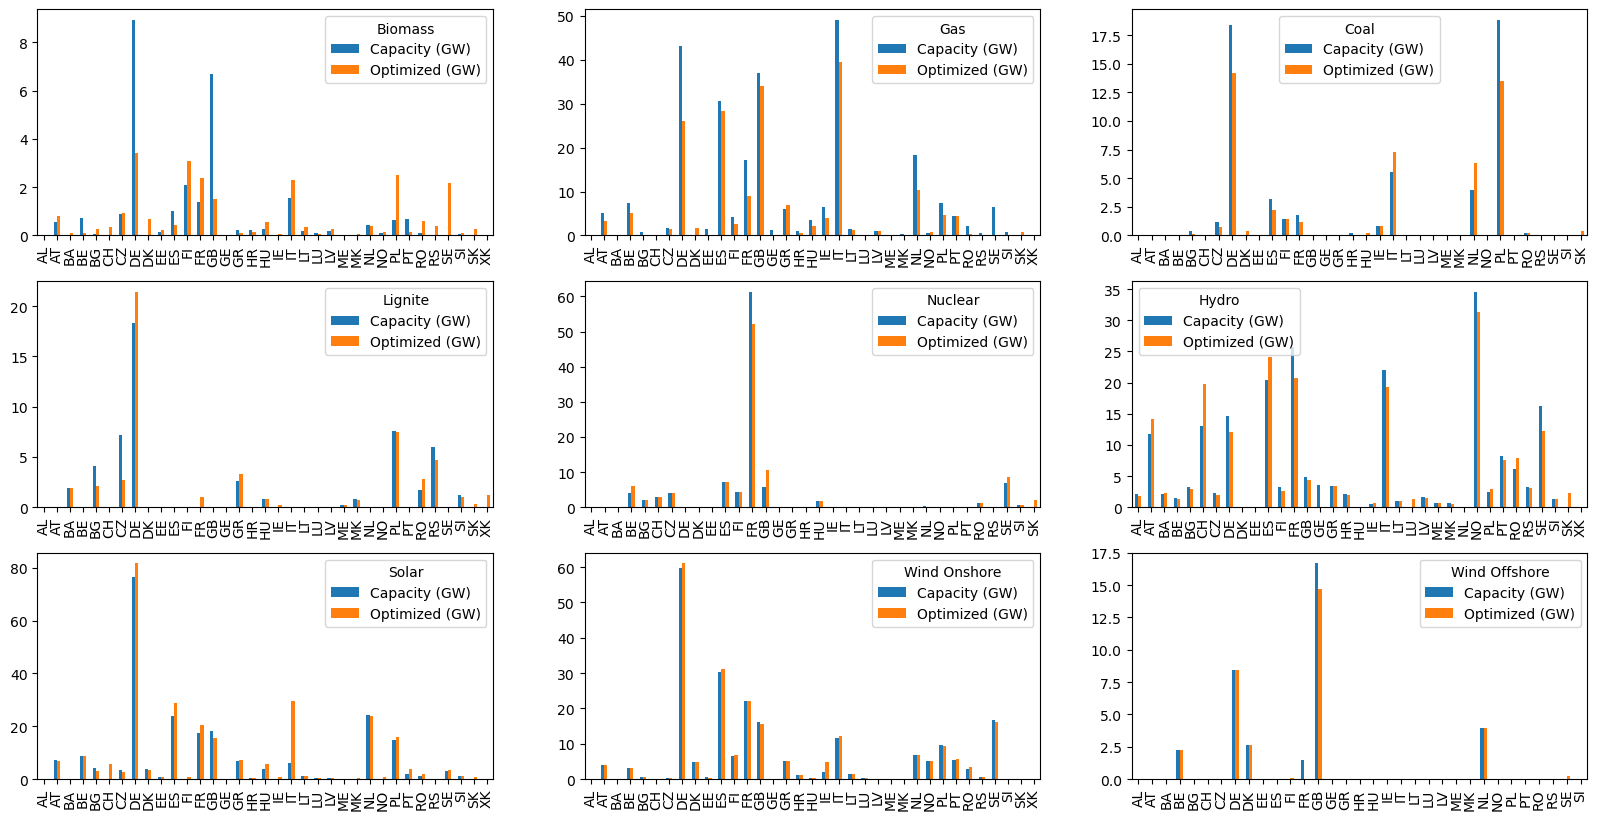

In [15]:
fig, axs = plt.subplots(3, 3, figsize=(20, 10))

for (nc, pypsa_carriers, comp), ax in zip(plot_carriers, axs.flatten()):

    if isinstance(comp, str):
        gen = getattr(n, comp).loc[getattr(n, comp).carrier.isin(pypsa_carriers), 'p_nom_opt']

        if comp == 'links':
            eta = n.links.loc[n.links.carrier.isin(pypsa_carriers), 'efficiency']
            gen = gen.mul(eta)
    else:
        gens = []
        for c, ps in zip(comp, pypsa_carriers):
            this_gen = getattr(n, c).loc[getattr(n, c).carrier == ps, 'p_nom_opt']
            gens.append(this_gen)
        gen = pd.concat(gens)

    gen = gen.groupby(gen.index.str[:2]).sum()

    df = pd.DataFrame({
        'Capacity (GW)': cap.loc[nc],
        'Optimized (GW)': gen
    }).fillna(0).mul(1e-3)

    df.plot.bar(ax=ax)
    ax.legend(title=nc)

plt.show()


In [201]:
n.generators.loc[n.generators.carrier == 'solar rooftop'].iloc[[0]].T

Generator,AL0 0 0 solar rooftop-2025
bus,AL0 0 low voltage
control,PQ
type,
p_nom,0.0
p_nom_mod,0.0
p_nom_extendable,True
p_nom_min,0.0
p_nom_max,5281.542575
p_min_pu,0.0
p_max_pu,1.0


In [ ]:
wind = n.generators.loc[n.generators.carrier == 'solar', ['p_nom', 'p_nom_opt', 'p_nom_extendable']]
wind = wind.groupby(wind.index.str[:2]).agg(
    {'p_nom': 'sum', 'p_nom_opt': 'sum', 'p_nom_extendable': 'max'}
)
wind

,p_nom,p_nom_opt,p_nom_extendable
Generator,,,
AL,162.000000,162.000000,False
AT,6832.686000,6832.686000,False
BA,123.720000,123.720000,False
BE,8547.100000,8547.100000,False
BG,2948.184000,2948.184000,False
CH,5839.920000,5839.920000,False
CZ,2505.695000,2505.695000,False
DE,81737.000000,81737.000000,False
DK,3522.000000,3522.000000,False


In [29]:
n = pypsa.Network(
    Path.cwd().parent / 'resources' / 'networks' / 'base_s_50_elec.nc'
)

INFO:pypsa.io:Imported network base_s_50_elec.nc has buses, carriers, generators, lines, links, loads, storage_units


In [30]:
n

Unnamed PyPSA Network
---------------------
Components:
 - Bus: 50
 - Carrier: 20
 - Generator: 629
 - Line: 97
 - Link: 67
 - Load: 50
 - StorageUnit: 68
Snapshots: 8760

In [36]:
n.generators.loc[n.generators.carrier == 'nuclear']

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
SE1 0 nuclear 65,SE1 0,PQ,,3261.0,0.0,False,3261.0,inf,0.0,0.817,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
SE1 0 nuclear 66,SE1 0,PQ,,1400.0,0.0,False,1400.0,inf,0.0,0.817,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
SE1 0 nuclear 67,SE1 0,PQ,,3956.0,0.0,False,3956.0,inf,0.0,0.817,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
FR0 0 nuclear 735,FR0 0,PQ,,2620.0,0.0,False,2620.0,inf,0.0,0.616,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
FR0 0 nuclear 736,FR0 0,PQ,,5320.0,0.0,False,5320.0,inf,0.0,0.616,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
FR0 0 nuclear 737,FR0 0,PQ,,2660.0,0.0,False,2660.0,inf,0.0,0.616,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
FR0 1 nuclear 738,FR0 1,PQ,,2670.0,0.0,False,2670.0,inf,0.0,0.616,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
FR0 0 nuclear 739,FR0 0,PQ,,3560.0,0.0,False,3560.0,inf,0.0,0.616,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
FR0 0 nuclear 740,FR0 0,PQ,,2620.0,0.0,False,2620.0,inf,0.0,0.616,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
